## 라이브러리 호출 및 데이터 로드

In [40]:
# 라이브러리 호출
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform
import ast
from collections import Counter
import json
from pprint import pprint
import warnings
import platform

# 통계용 라이브러리 호출
from scipy import stats
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
from matplotlib.patches import Patch
import pingouin as pg
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize, proportion_confint
from statsmodels.stats.power import NormalIndPower

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 컬럼 너비 제한 해제
pd.set_option('display.max_colwidth', None)

In [41]:
# 데이터 로드
df_champion = pd.read_csv('../../유저단위_게임데이터_상위랭커보존-stats_champion_1.csv')
df_combination = pd.read_csv('../../유저단위_게임데이터_상위랭커보존-stats_combination_1.csv')
df_champion_with_items = pd.read_csv("../../유저단위_게임데이터_상위랭커보존-stats_champion_items_1.csv")

---
### **경기데이터와 챔피언 데이터가 결합된 테이블**
- `df_champion`

In [42]:
df_champion.info()

<class 'pandas.DataFrame'>
RangeIndex: 396204 entries, 0 to 396203
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   user_id           396204 non-null  str  
 1   game_id           396204 non-null  str  
 2   user_tier         396204 non-null  str  
 3   ranked            396204 non-null  int64
 4   flag_1            396204 non-null  int64
 5   flag_2            396204 non-null  int64
 6   active_synergies  396204 non-null  str  
 7   top4_flag         396204 non-null  bool 
 8   ranked_1          396204 non-null  bool 
 9   champions         396204 non-null  str  
dtypes: bool(2), int64(3), str(5)
memory usage: 24.9 MB


In [43]:
df_champion.head(1)

,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,champions
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,"[{'name': 'ziggs', 'star': 1, 'cost': 1, 'origin': 'Rebel', 'class': ""['Demolitionist']""}, {'name': 'ashe', 'star': 1, 'cost': 3, 'origin': 'Celestial', 'class': ""['Sniper']""}, {'name': 'chogath', 'star': 1, 'cost': 4, 'origin': 'Void', 'class': ""['Brawler']""}, {'name': 'ekko', 'star': 1, 'cost': 5, 'origin': 'Cybernetic', 'class': ""['Infiltrator']""}]"


#### 🔻분석단위를 챔피언 단위로 변경
- 하나의 row = 한 유저가 참여한 하나의 게임
- 챔피언마다 name, star, cost, origin, class 정보가 담겨있음 

In [44]:
# champions 컬럼 문자열 → 리스트로 변환
df_champion['champions'] = df_champion['champions'].apply(ast.literal_eval)

# 챔피언 단위로 분리 (explode)
df_champ_exploded = df_champion.explode('champions')

# 딕셔너리 컬럼 분리
df_champ_exploded = pd.concat([
    df_champ_exploded.drop(columns='champions'),
    df_champ_exploded['champions'].apply(pd.Series)
], axis=1)
# champion 컬럼 분리 전
# champions = {'name': 'ziggs', 'star': 1, 'cost': 1, 'origin': 'Rebel', 'class': ['Demolitionist']}

# champion 컬럼 분리 후
# user_id    game_id  ranked  top4_flag   name   star  cost  origin         class
# KR-USER-1  KR_...     5       False     ziggs   1     1    Rebel     [Demolitionist]
# KR-USER-1  KR_...     5       False     ashe    1     3   Celestial     [Sniper]

print(df_champ_exploded.shape)
display(df_champ_exploded.head(1))

(3130701, 14)


,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,name,star,cost,origin,class
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,ziggs,1,1,Rebel,['Demolitionist']


In [45]:
# flag_1 제거 (챔피언 정보 누락된 row 제거)
df_champ_exploded = df_champ_exploded[df_champ_exploded['flag_1'] == 0]

print(df_champ_exploded.shape)

(3130701, 14)


---
#### **➡️ 유저가 가장 많이 선택한 챔피언 Top 5 선정**
- 티어별로도 확인하고, 전체 티어에서도 확인
- 전체 티어에서 많이 선택된 챔피언은 평균 등수에 대해 통계 검정 수행

In [46]:
# (1) 유저가 가장 많이 선택한 챔피언 Top 5 (티어별)
df_champ_exploded.groupby('user_tier')['name'].value_counts().groupby('user_tier').head(5)

user_tier     name       
challenger    vi             27744
              blitzcrank     24145
              ezreal         23573
              missfortune    22516
              kassadin       21862
diamond       blitzcrank     24825
              vi             23697
              kassadin       23689
              malphite       22607
              wukong         21709
grand_master  vi             27141
              blitzcrank     26083
              kassadin       24003
              ezreal         23404
              wukong         22986
master        vi             25423
              blitzcrank     24608
              kassadin       22178
              ezreal         22084
              missfortune    21200
platinum      blitzcrank     20379
              vi             19549
              wukong         17725
              ezreal         17442
              malphite       17376
Name: count, dtype: int64

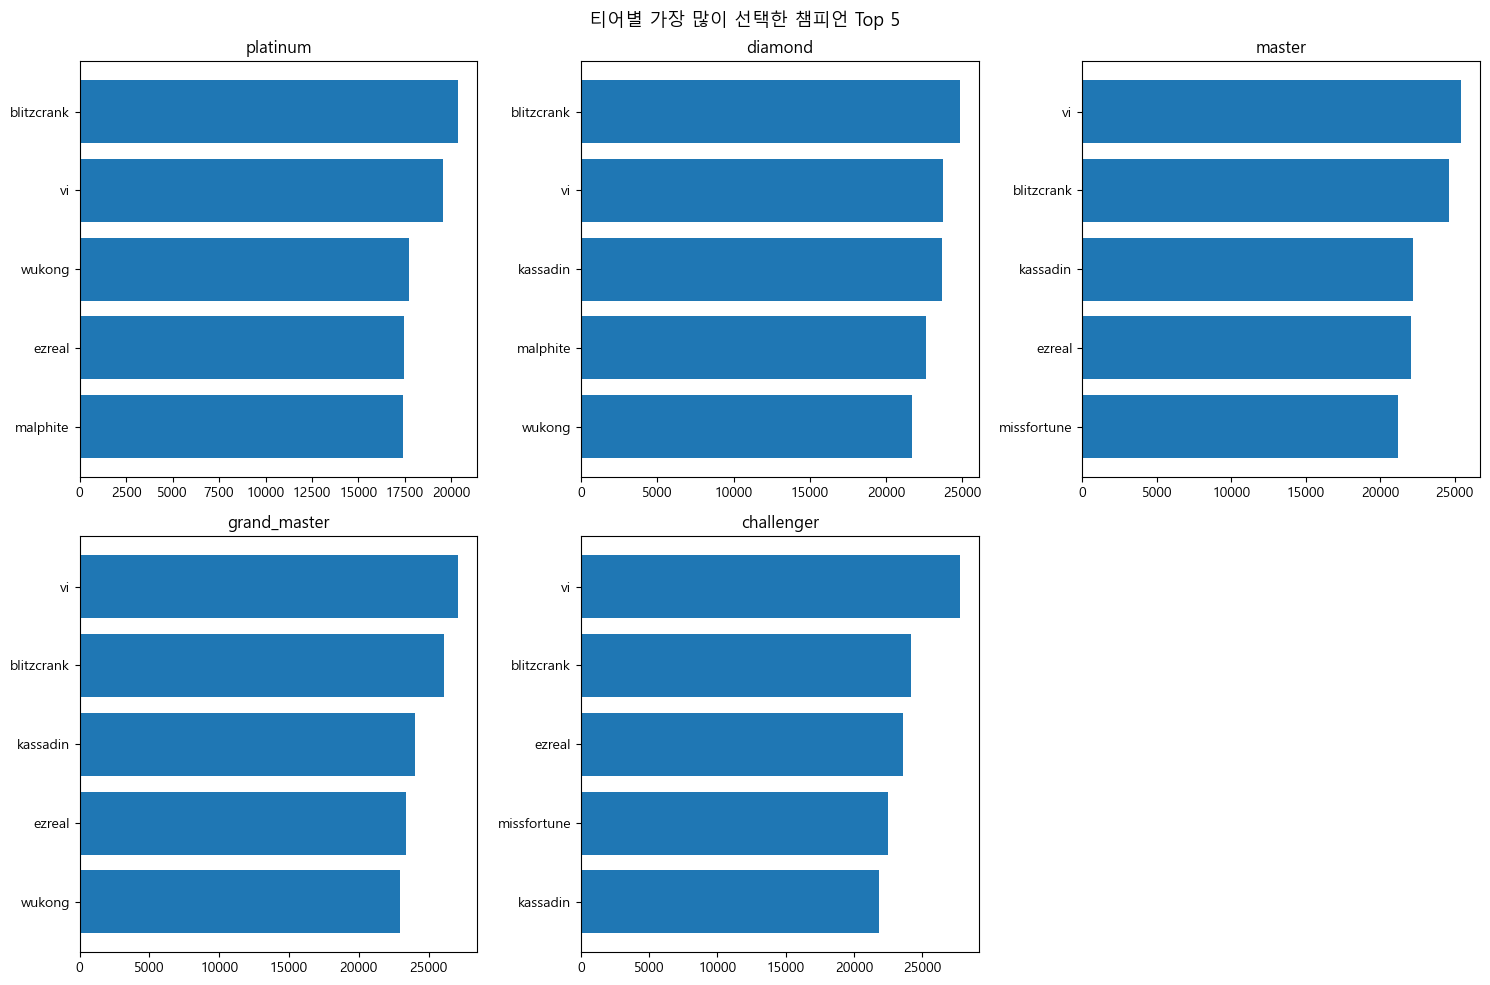

In [47]:
# 티어 순서 지정
tier_order = ['platinum', 'diamond', 'master', 'grand_master', 'challenger']

# 결과를 변수에 저장
top5_champ_by_tier = (
    df_champ_exploded
    .groupby('user_tier')['name']
    .value_counts()
    .groupby('user_tier')
    .head(5)
    .reset_index()
)

# 막대그래프 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, tier in zip(axes, tier_order):
    group = top5_champ_by_tier[top5_champ_by_tier['user_tier'] == tier]
    ax.barh(group['name'], group['count'])
    ax.set_title(tier)
    ax.invert_yaxis()  # 1위가 위로

# 빈 subplot 제거
axes[-1].set_visible(False)

plt.suptitle('티어별 가장 많이 선택한 챔피언 Top 5', fontsize=13)
plt.tight_layout()
plt.show()

In [48]:
# (2) 티어 구분 없이 가장 많이 선택된 챔피언 Top 5
df_champ_exploded['name'].value_counts().head(5)

name
vi             123554
blitzcrank     120040
kassadin       108656
ezreal         105788
missfortune    105382
Name: count, dtype: int64

In [49]:
# (3) 티어와 관계없이 가장 많이 선택된 vi, blitzcrank가 포함되어 있을 때 평균 성적
# vi, blitzcrank의 평균 등수를 활용한 Welch's T-test도 수행
# 표본의 크기가 매우 커서 CLT에 의해 t-test 적용 가능

target_champs = ['vi', 'blitzcrank']

alpha = 0.05
overall_mean_1 = df_champ_exploded['ranked'].mean() # 전체 유저의 평균 등수

for champ in target_champs:
    data = df_champ_exploded[df_champ_exploded['name'] == champ]['ranked']
    top4_ratio = (data <= 4).mean()
    
    # Welch's t-test (popmean: 귀무가설에서의 예상값)
    # 귀무가설: 전체 평균 등수와 같을 것이다.
    # 대립가설: 전체 평균 등수와 다를 것이다
    t_stat, p_val = stats.ttest_1samp(data, popmean=overall_mean_1)
    
    print(f'[{champ}]')
    print(f'평균 등수: {data.mean():.2f}')
    print(f't_stat: {t_stat:.4f}')
    print(f'p_val: {p_val:.4e}')
    print(f'Top 4 비율: {top4_ratio:.2%}')
    
    if p_val < alpha:
        direction = '전체 평균보다 좋음' if t_stat < 0 else '전체 평균보다 나쁨'
        print(f' → 유의미한 차이 있음 ({direction})')
    else:
        print(f' → 유의미한 차이 없음')
    print()
    
# [결과 요약]
# vi: 픽률 1위, 평균 등수 4.32 → 전체 평균(4.38)보다 유의미하게 좋음 → 너프 후보로 고려 가능
# blitzcrank: 픽률 2위, 평균 등수 4.41 → 전체 평균(4.38)보다 유의미하게 나쁨 → 과대평가된 챔피언일 가능성 o

[vi]
평균 등수: 4.32
t_stat: -9.6322
p_val: 5.9495e-22
Top 4 비율: 53.44%
 → 유의미한 차이 있음 (전체 평균보다 좋음)

[blitzcrank]
평균 등수: 4.41
t_stat: 4.9568
p_val: 7.1779e-07
Top 4 비율: 51.70%
 → 유의미한 차이 있음 (전체 평균보다 나쁨)



---
#### **➡️ 유저가 가장 많이 선택한 시너지 Top 5 선정**
- 티어별로도 확인하고, 전체 티어에서도 확인

In [50]:
# class 컬럼 확인
print(df_champ_exploded['class'].dtype)
display(df_champ_exploded['class'].head(1))

str


0    ['Demolitionist']
Name: class, dtype: str

In [51]:
# 문자열 → 리스트 변환
df_champ_exploded['class'] = df_champ_exploded['class'].apply(ast.literal_eval)

# 시너지 단위로 분리
df_synergy_exploded = df_champ_exploded.explode('class')

# (4) 전체 유저가 가장 많이 선택한 시너지 Top 5
print('[전체 유저가 가장 많이 선택한 시너지 Top 5]')
display(df_synergy_exploded['class'].value_counts().head(5))
print()

# (5) 티어별로 유저가 가장 많이 선택한 시너지 Top 5
print('[티어별로 유저가 가장 많이 선택한 시너지 Top 5]')
top5_synergy_by_tier = (
    df_synergy_exploded
    .groupby('user_tier')['class']
    .value_counts()
    .groupby('user_tier')
    .head(5)
    .reset_index()
)
display(top5_synergy_by_tier)

[전체 유저가 가장 많이 선택한 시너지 Top 5]


class
Brawler        437345
Blaster        428334
Blademaster    407834
Sorcerer       350769
Vanguard       339726
Name: count, dtype: int64


[티어별로 유저가 가장 많이 선택한 시너지 Top 5]


,user_tier,class,count
0,challenger,Blaster,91208
1,challenger,Brawler,88695
2,challenger,Blademaster,78710
3,challenger,Sorcerer,72460
4,challenger,Vanguard,70293
5,diamond,Brawler,92048
6,diamond,Blademaster,91083
7,diamond,Blaster,85087
8,diamond,Vanguard,61617
9,diamond,Mana-Reaver,61401


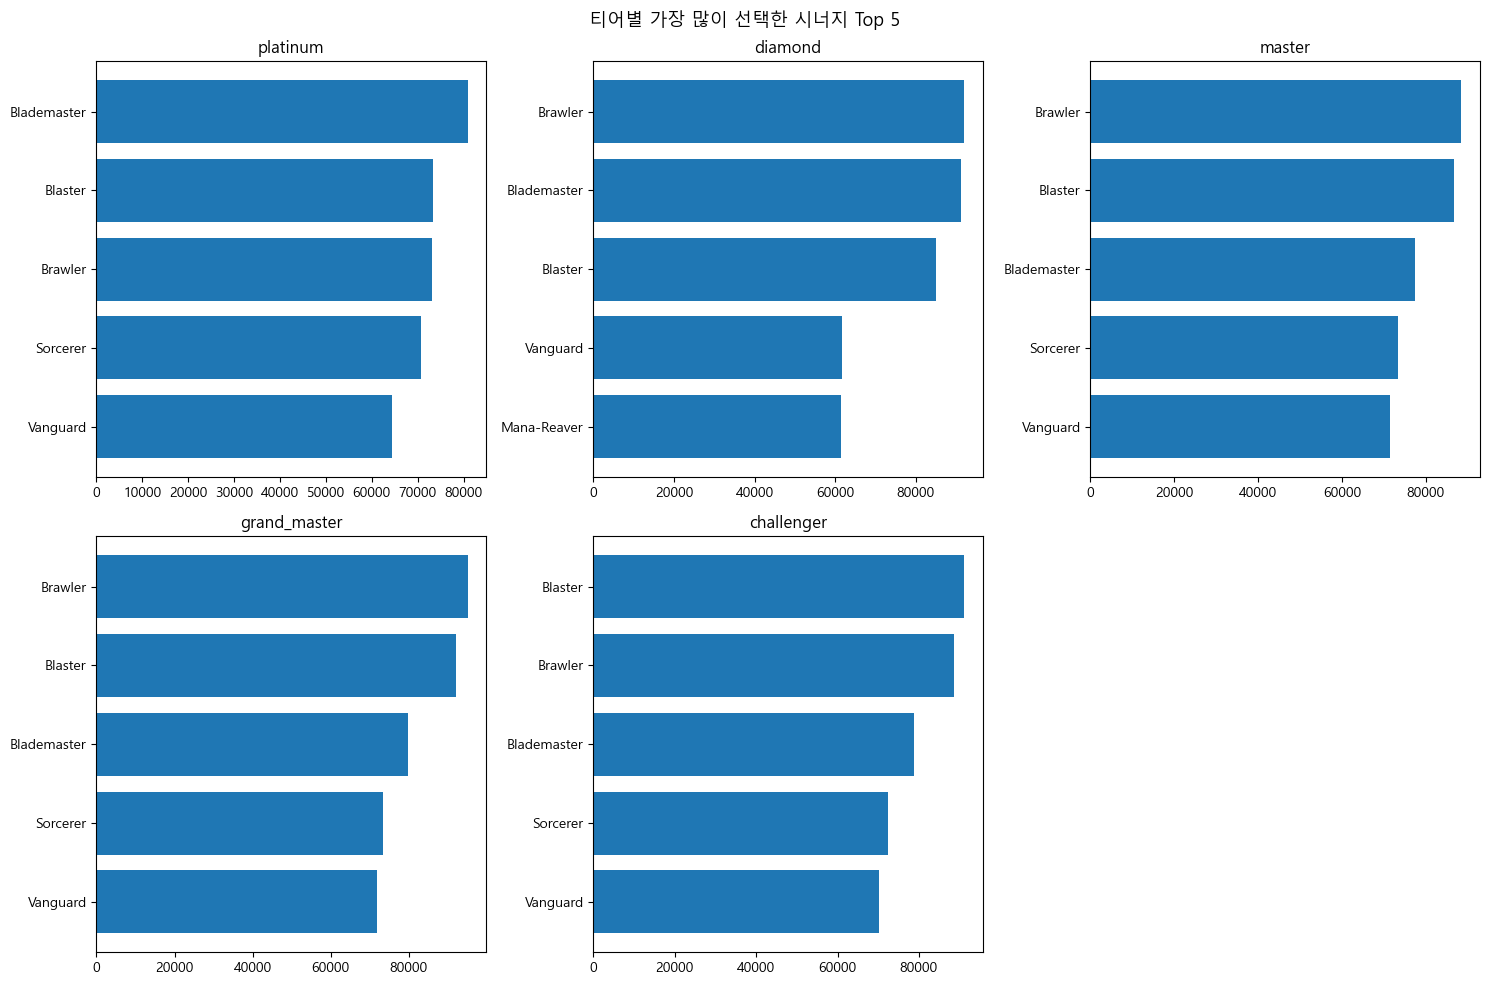

In [52]:
# (5)의 결과를 막대 그래프로 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, tier in zip(axes, tier_order):
    group = top5_synergy_by_tier[top5_synergy_by_tier['user_tier'] == tier]
    ax.barh(group['class'], group['count'])
    ax.set_title(tier)
    ax.invert_yaxis()  # 1위가 위로

# 빈 subplot 제거
axes[-1].set_visible(False)

plt.suptitle('티어별 가장 많이 선택한 시너지 Top 5', fontsize=13)
plt.tight_layout()
plt.show()

---
#### **➡️ 유저가 가장 많이 선택한 콤비네이션 Top 5 선정**
- 티어별로도 확인하고, 전체 티어에서도 확인

In [53]:
print(df_combination.info())
display(df_combination.head(1))

<class 'pandas.DataFrame'>
RangeIndex: 396239 entries, 0 to 396238
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   gameid               396239 non-null  str  
 1   user_tier            396239 non-null  str  
 2   ranked               396239 non-null  int64
 3   user_id              396239 non-null  str  
 4   flag_1               396239 non-null  int64
 5   flag_2               396239 non-null  int64
 6   active_synergies     396239 non-null  str  
 7   top4_flag            396239 non-null  bool 
 8   ranked_1             396239 non-null  bool 
 9   combination_rebuild  396239 non-null  str  
dtypes: bool(2), int64(3), str(5)
memory usage: 24.9 MB
None


,gameid,user_tier,ranked,user_id,flag_1,flag_2,active_synergies,top4_flag,ranked_1,combination_rebuild
0,KR_4291707834,platinum,5,KR-USER-1,0,0,{},False,False,"{'Cybernetic': 1, 'Demolitionist': 1, 'Infiltrator': 1, 'Rebel': 1, 'Brawler': 1, 'Celestial': 1, 'Void': 1, 'Sniper': 1}"


In [54]:
# (6) 전체 유저 기준에서 확인
# 둘 다 문자열 → 딕셔너리 변환
df_combination['active_synergies'] = df_combination['active_synergies'].apply(ast.literal_eval)
df_combination['combination_rebuild'] = df_combination['combination_rebuild'].apply(ast.literal_eval)

# 활성화된 조합 리스트 추출
df_combination['combo_list_active'] = df_combination['active_synergies'].apply(
    lambda x: list(x.keys()) if x else []
)

# 보유한 조합 리스트 추출
df_combination['combo_list_rebuild'] = df_combination['combination_rebuild'].apply(
    lambda x: list(x.keys()) if x else []
)

# 가장 많이 활성화한 콤비네이션 Top 5
df_combo_active_exploded = df_combination.explode('combo_list_active')
print('[전체 유저가 가장 많이 활성화한 콤비네이션 Top 5]')
display(df_combo_active_exploded['combo_list_active'].value_counts().head(5))
print('='*50)

# 가장 많이 보유한 콤비네이션 Top 5
df_combo_rebuild_exploded = df_combination.explode('combo_list_rebuild')
print('[전체 유저가 가장 많이 보유한 콤비네이션 Top 5]')
display(df_combo_rebuild_exploded['combo_list_rebuild'].value_counts().head(5))

[전체 유저가 가장 많이 활성화한 콤비네이션 Top 5]


combo_list_active
Chrono        200384
Celestial     137136
Mercenary     127057
Blaster       115469
ManaReaver    113311
Name: count, dtype: int64

[전체 유저가 가장 많이 보유한 콤비네이션 Top 5]


combo_list_rebuild
Chrono        262897
Cybernetic    210292
Vanguard      191019
DarkStar      189045
Celestial     180392
Name: count, dtype: int64

In [60]:
# (7) 티어별 유저 기준에서 확인
# 활성화한 조합 Top 5
top5_active_by_tier = (
    df_combo_active_exploded
    .groupby('user_tier')['combo_list_active']
    .value_counts()
    .groupby('user_tier')
    .head(5)
    .reset_index()
)

display(top5_active_by_tier)

,user_tier,combo_list_active,count
0,challenger,Chrono,38273
1,challenger,Celestial,28024
2,challenger,Blaster,25234
3,challenger,Mercenary,24362
4,challenger,ManaReaver,23896
5,diamond,Chrono,44033
6,diamond,Mercenary,28890
7,diamond,Celestial,28364
8,diamond,ManaReaver,24393
9,diamond,Blademaster,22950


In [61]:
# 보유한 조합 Top 5
top5_rebuild_by_tier = (
    df_combo_rebuild_exploded
    .groupby('user_tier')['combo_list_rebuild']
    .value_counts()
    .groupby('user_tier')
    .head(5)
    .reset_index()
)

display(top5_rebuild_by_tier)

,user_tier,combo_list_rebuild,count
0,challenger,Chrono,49860
1,challenger,Cybernetic,42271
2,challenger,Vanguard,40567
3,challenger,Valkyrie,37310
4,challenger,Blaster,37012
5,diamond,Chrono,56554
6,diamond,Cybernetic,44308
7,diamond,DarkStar,38044
8,diamond,Valkyrie,37455
9,diamond,Blademaster,36878


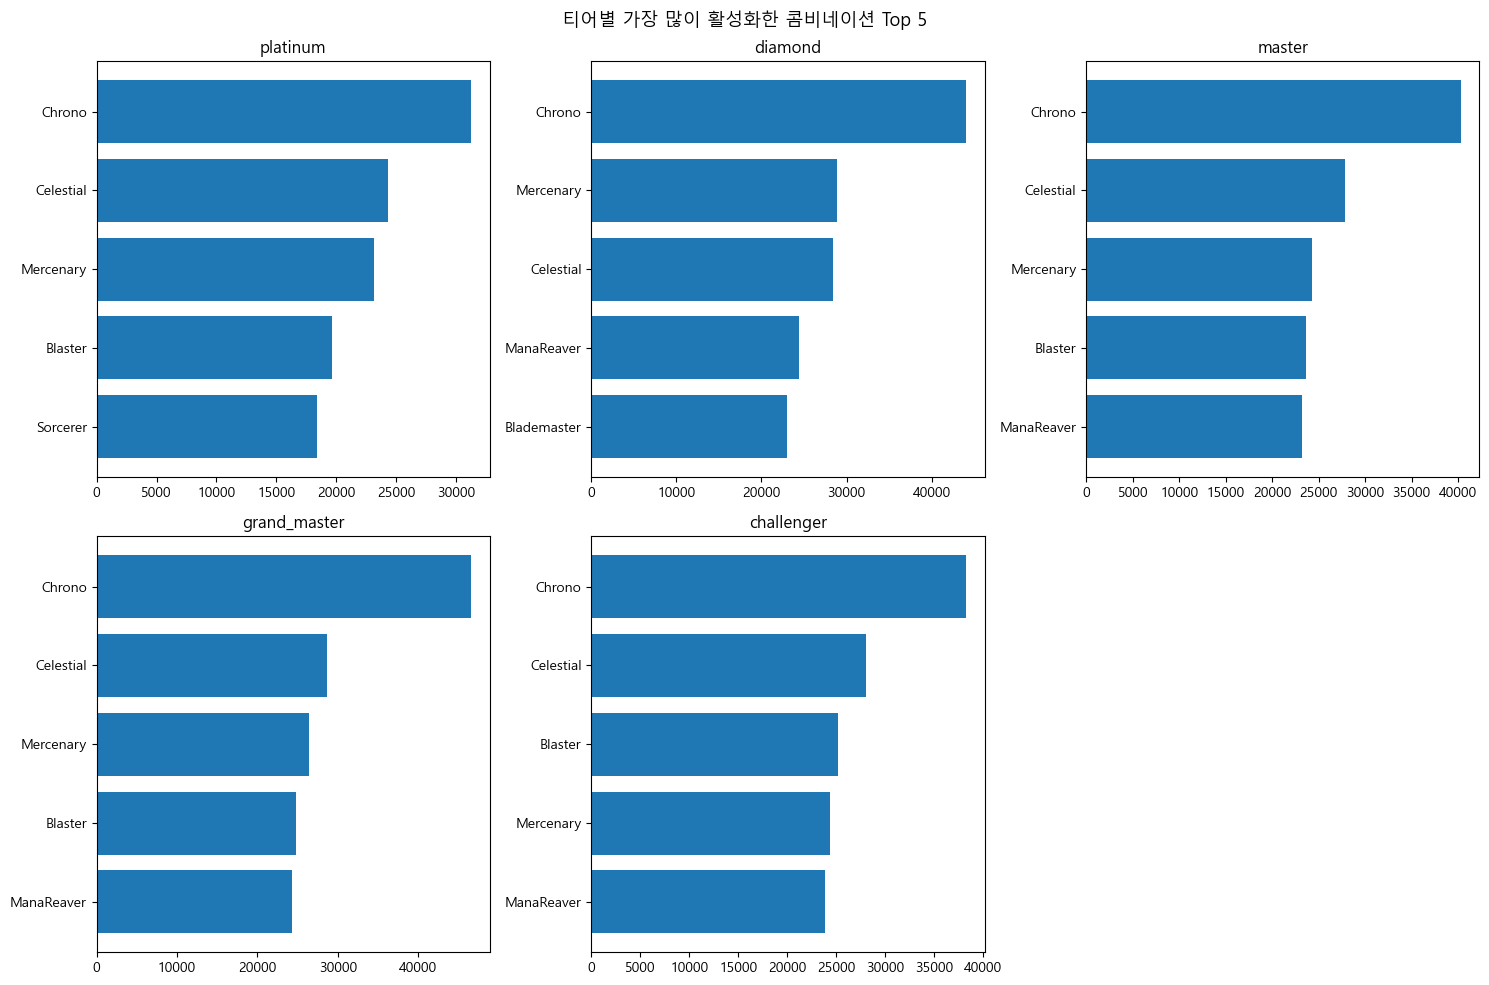

In [63]:
# 시각화 - 활성화한 조합 Top 5
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, tier in zip(axes, tier_order):
    group = top5_active_by_tier[top5_active_by_tier['user_tier'] == tier]
    ax.barh(group['combo_list_active'], group['count'])
    ax.set_title(tier)
    ax.invert_yaxis()

axes[-1].set_visible(False) # 마지막 6번쨰 서브플롯 삭제
plt.suptitle('티어별 가장 많이 활성화한 콤비네이션 Top 5', fontsize=13)
plt.tight_layout()
plt.show()

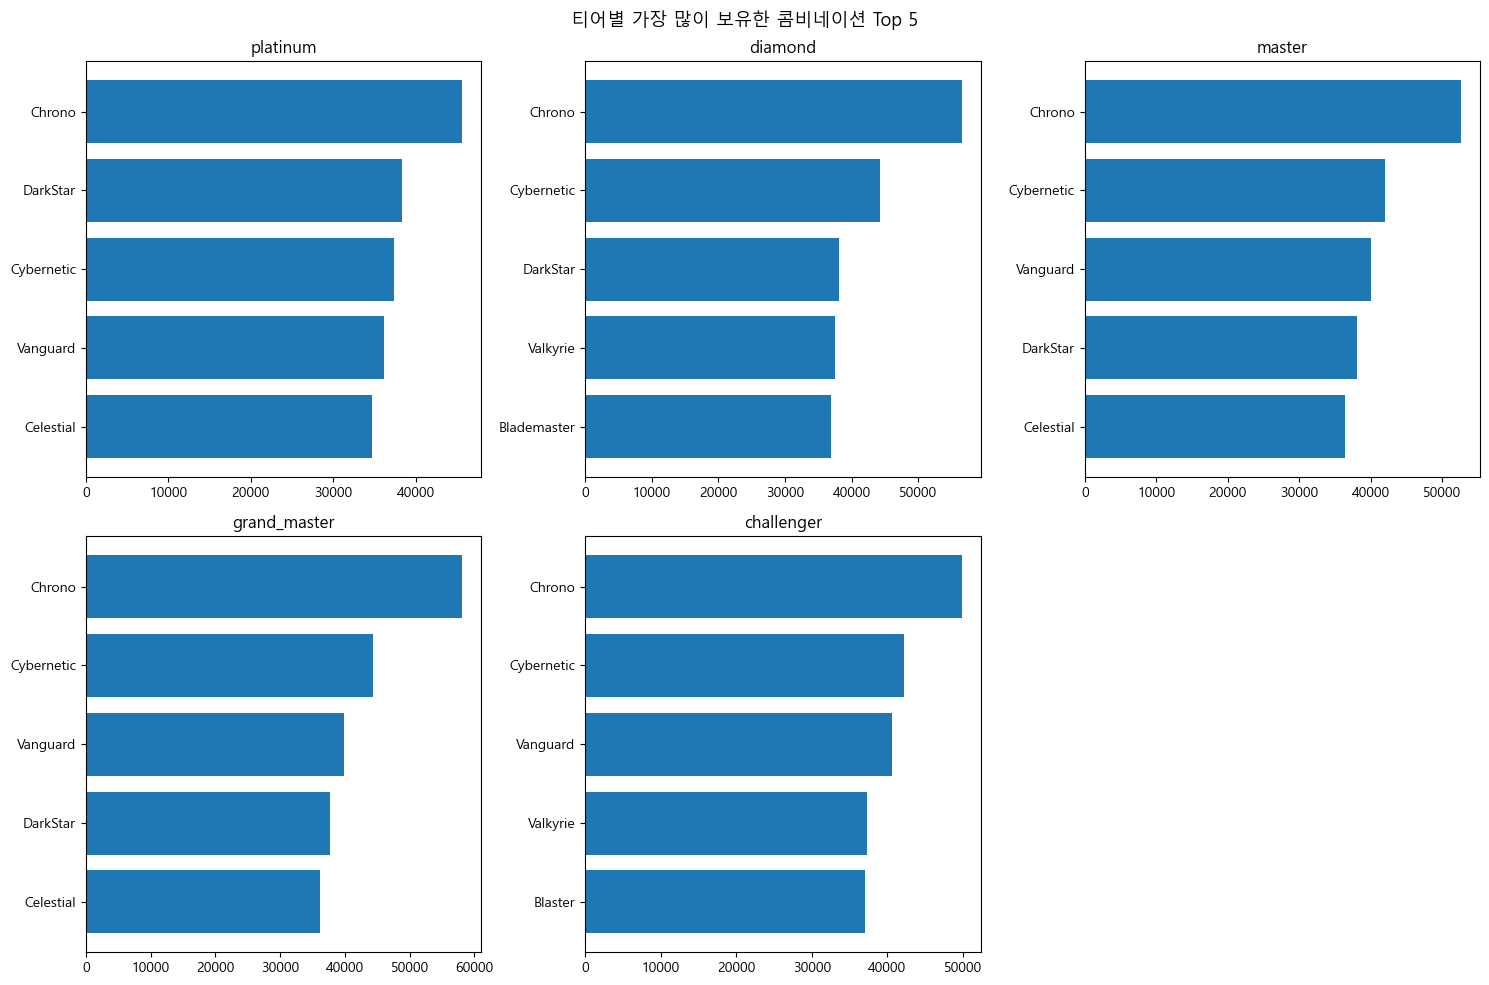

In [64]:
# 시각화 - 보유한 조합 Top 5
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, tier in zip(axes, tier_order):
    group = top5_rebuild_by_tier[top5_rebuild_by_tier['user_tier'] == tier]
    ax.barh(group['combo_list_rebuild'], group['count'])
    ax.set_title(tier)
    ax.invert_yaxis()

axes[-1].set_visible(False)
plt.suptitle('티어별 가장 많이 보유한 콤비네이션 Top 5', fontsize=13)
plt.tight_layout()
plt.show()

---
---
### **경기데이터와 챔피언 데이터, 아이템 데이터가 결합된 테이블**
- `df_champion_with_items`